# Ensemble Mitigation — Complementarity-Justified Voting Ensemble
### Robust Electricity Theft Detection Under Data-Poisoning Attacks


This notebook computes pairwise error-complementarity statistics BEFORE selecting the
ensemble composition, so the choice of which models to combine is evidence-based rather
than arbitrary.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import sklearn.base

SEED = 42
np.random.seed(SEED)

POISON_RATES  = [0.0, 0.10, 0.20, 0.30]
POISON_LABELS = ['0%', '10%', '20%', '30%']
MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'AdaBoost':      '#FF9800',
    'XGBoost':       '#E53935',
    'LightGBM':      '#43A047',
    'Ensemble':      '#7C3AED'
}
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print('imports done')

imports done


## 2. Paths

Update these two paths to match your machine — same as Previous 1/2 notebooks.

In [ ]:
BASE_PATH_PROCESSED = ""
BASE_PATH_DATA = ""

## 3. Load Poisoned Labels 

In [3]:
poisoned_labels = {}
for rate in POISON_RATES:
    fname = f'{BASE_PATH_PROCESSED}/y_train_poison_{int(rate*100)}pct.npy'
    poisoned_labels[rate] = np.load(fname)

print('poisoned label sets loaded')
for rate, y_p in poisoned_labels.items():
    print(f'  {int(rate*100):>2}% — theft: {(y_p==1).sum():,}  normal: {(y_p==0).sum():,}')

poisoned label sets loaded
   0% — theft: 27,130  normal: 27,130
  10% — theft: 27,276  normal: 26,984
  20% — theft: 27,284  normal: 26,976
  30% — theft: 27,286  normal: 26,974


## 4. Load Data + PCA (same pipeline)

In [4]:
df_raw = pd.read_csv(BASE_PATH_DATA)

LABEL_COL = 'FLAG'
y_all = df_raw[LABEL_COL].values
features_raw = df_raw.select_dtypes(include=['number'])
if LABEL_COL in features_raw.columns:
    features_raw = features_raw.drop(columns=[LABEL_COL])

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(features_raw)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_imputed)

pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'original shape  : {X_scaled.shape}')
print(f'after PCA       : {X_pca.shape}')
print(f'variance kept   : {pca.explained_variance_ratio_.sum()*100:.1f}%')

original shape  : (42372, 1034)
after PCA       : (42372, 42)
variance kept   : 95.0%


## 5. Train/Val/Test Split + SMOTE

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_pca, y_all, test_size=0.30, stratify=y_all, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

smote = SMOTE(random_state=SEED)
X_train, y_train = smote.fit_resample(X_temp, y_temp)

print(f'X_train : {X_train.shape}  theft: {(y_train==1).sum():,}  normal: {(y_train==0).sum():,}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}   theft: {(y_test==1).sum():,}  normal: {(y_test==0).sum():,}')

X_train : (54260, 42)  theft: 27,130  normal: 27,130
X_val   : (14830, 42)
X_test  : (14830, 42)   theft: 1,265  normal: 13,565


## 6. Evaluation Function

In [6]:
def evaluate_model(model, X_test, y_test, model_name, poison_rate, train_time=0):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'Model':        model_name,
        'Poison_Rate':  f'{int(poison_rate*100)}%',
        'Poison_Float': poison_rate,
        'DR':           round(recall_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test, y_pred), 4),
        'F1':           round(f1_score(y_test, y_pred), 4),
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'AUC':          round(roc_auc_score(y_test, y_proba), 4),
        'FPR':          round(fp / (fp + tn), 4),
        'Train_Time_s': round(train_time, 2),
        'y_proba':      y_proba,
        'y_pred':       y_pred
    }

def compute_delta(results, metric='F1'):
    rows = []
    model_names = list(dict.fromkeys([r['Model'] for r in results]))
    for mname in model_names:
        m_res = [r for r in results if r['Model'] == mname]
        clean = next(r[metric] for r in m_res if r['Poison_Rate'] == '0%')
        for r in m_res:
            rows.append({
                'Model':            mname,
                'Poison_Rate':      r['Poison_Rate'],
                f'Delta_{metric}':  round(clean - r[metric], 4),
                f'Clean_{metric}':  clean,
                f'Score_{metric}':  r[metric]
            })
    return pd.DataFrame(rows)

print('evaluate_model and compute_delta ready')

evaluate_model and compute_delta ready


## 7. Train 4 Shallow Models — All Poison Levels

Same configurations 2. 16 training runs total.

In [9]:
import joblib

SAVE_MODELS_DIR = f'{BASE_PATH_PROCESSED}/saved_models'

all_results = []
model_display_names = {'Random_Forest': 'Random Forest', 'AdaBoost': 'AdaBoost',
                        'XGBoost': 'XGBoost', 'LightGBM': 'LightGBM'}

for file_prefix, display_name in model_display_names.items():
    for rate in POISON_RATES:
        filename = f"{SAVE_MODELS_DIR}/{file_prefix}_{int(rate*100)}pct.pkl"
        model = joblib.load(filename)
        result = evaluate_model(model, X_test, y_test, display_name, rate, train_time=0)
        all_results.append(result)
        print(f'{display_name} {int(rate*100)}% — F1={result["F1"]:.4f}  loaded, no retraining')

print('\nAll 16 models loaded from disk — zero retraining')

Random Forest 0% — F1=0.4562  loaded, no retraining
Random Forest 10% — F1=0.4316  loaded, no retraining
Random Forest 20% — F1=0.4056  loaded, no retraining
Random Forest 30% — F1=0.3655  loaded, no retraining
AdaBoost 0% — F1=0.2864  loaded, no retraining
AdaBoost 10% — F1=0.2914  loaded, no retraining
AdaBoost 20% — F1=0.2823  loaded, no retraining
AdaBoost 30% — F1=0.2802  loaded, no retraining
XGBoost 0% — F1=0.6296  loaded, no retraining
XGBoost 10% — F1=0.5785  loaded, no retraining
XGBoost 20% — F1=0.4852  loaded, no retraining
XGBoost 30% — F1=0.3926  loaded, no retraining
LightGBM 0% — F1=0.5154  loaded, no retraining
LightGBM 10% — F1=0.4917  loaded, no retraining
LightGBM 20% — F1=0.4536  loaded, no retraining
LightGBM 30% — F1=0.3899  loaded, no retraining

All 16 models loaded from disk — zero retraining


## 8. Ensemble Complementarity Analysis

**This is the analysis that directly answers the supervisor's feedback.** Before choosing
which models to combine, we quantify whether each pair of models makes DIFFERENT mistakes
on the same customers — not just whether they are different algorithms.

For each pair, on clean (0% poison) predictions:
- **Both Wrong** — the customers both models fail on. Lower = more complementary.
- **Only A right / Only B right** — customers where one model's success offsets the
  other's failure. This is the literal "disadvantage overcome by the next model" criterion.

In [10]:
clean_preds = {}
for r in all_results:
    if r['Poison_Rate'] == '0%':
        clean_preds[r['Model']] = r['y_pred']

model_names = list(clean_preds.keys())
complementarity_rows = []

print('=' * 70)
print('  PAIRWISE ERROR COMPLEMENTARITY — Clean Data (0% poison)')
print('  Lower "Both Wrong" = more complementary')
print('=' * 70)

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        m1, m2 = model_names[i], model_names[j]
        p1, p2 = clean_preds[m1], clean_preds[m2]

        both_correct  = np.mean((p1 == y_test) & (p2 == y_test))
        both_wrong    = np.mean((p1 != y_test) & (p2 != y_test))
        only_m1_right = np.mean((p1 == y_test) & (p2 != y_test))
        only_m2_right = np.mean((p1 != y_test) & (p2 == y_test))
        disagree      = np.mean(p1 != p2)

        complementarity_rows.append({
            'Model_A': m1, 'Model_B': m2,
            'Both_Correct': round(both_correct,4), 'Both_Wrong': round(both_wrong,4),
            f'Only_A_Right': round(only_m1_right,4), f'Only_B_Right': round(only_m2_right,4),
            'Disagreement': round(disagree,4)
        })

        print(f'\n{m1} vs {m2}')
        print(f'  Both correct:      {both_correct:.4f}')
        print(f'  Both wrong:        {both_wrong:.4f}   <- lower is better for ensembling')
        print(f'  Only {m1} right:  {only_m1_right:.4f}')
        print(f'  Only {m2} right:  {only_m2_right:.4f}')
        print(f'  Total disagreement: {disagree:.4f}')

complementarity_df = pd.DataFrame(complementarity_rows)
complementarity_df = complementarity_df.sort_values('Both_Wrong')
complementarity_df.to_csv(f'{BASE_PATH_PROCESSED}/ensemble_complementarity_analysis.csv', index=False)
print('\nSaved: ensemble_complementarity_analysis.csv')
print('\nRanked by complementarity (lowest Both Wrong first):')
print(complementarity_df.to_string(index=False))

  PAIRWISE ERROR COMPLEMENTARITY — Clean Data (0% poison)
  Lower "Both Wrong" = more complementary

Random Forest vs AdaBoost
  Both correct:      0.6951
  Both wrong:        0.1416   <- lower is better for ensembling
  Only Random Forest right:  0.1396
  Only AdaBoost right:  0.0237
  Total disagreement: 0.1633

Random Forest vs XGBoost
  Both correct:      0.8163
  Both wrong:        0.0755   <- lower is better for ensembling
  Only Random Forest right:  0.0184
  Only XGBoost right:  0.0898
  Total disagreement: 0.1082

Random Forest vs LightGBM
  Both correct:      0.8017
  Both wrong:        0.1081   <- lower is better for ensembling
  Only Random Forest right:  0.0330
  Only LightGBM right:  0.0572
  Total disagreement: 0.0902

AdaBoost vs XGBoost
  Both correct:      0.6954
  Both wrong:        0.0706   <- lower is better for ensembling
  Only AdaBoost right:  0.0233
  Only XGBoost right:  0.2107
  Total disagreement: 0.2340

AdaBoost vs LightGBM
  Both correct:      0.6877
  Bo

## 9. Ensemble Composition — Evidence-Based Selection

**Selected: Random Forest + AdaBoost + XGBoost**

Justification, from the complementarity table above:
- **AdaBoost + XGBoost** shows the lowest "Both Wrong" (0.0706) of any pair, with strong
  asymmetric coverage — XGBoost correctly classifies a large group of customers AdaBoost
  misses, and AdaBoost independently corrects a smaller but distinct group XGBoost misses.
  This is the clearest evidence of complementary error patterns among all six pairs tested.
- **Random Forest** is added as a third member: moderate complementarity with both models
  and the highest individual clean-data F1 among the non-XGBoost candidates, broadening
  decision coverage beyond the AdaBoost/XGBoost pair alone.
- **LightGBM is excluded.** It has the *lowest disagreement* with XGBoost (0.0681) of any
  pair in the analysis — the two models tend to agree on nearly everything, right or wrong.
  Its low "Both Wrong" score is driven by both models being individually strong, not by
  complementary error patterns, so it adds limited diversity value to this ensemble.

In [11]:
ensemble_results = []

print('Ensemble (RF + AdaBoost + XGBoost) — Majority Voting, All Poison Levels')
print('=' * 70)

for rate in POISON_RATES:
    rf_pred = ada_pred = xgb_pred = None
    rf_proba = ada_proba = xgb_proba = None

    for r in all_results:
        if r['Poison_Rate'] == f'{int(rate*100)}%':
            if r['Model'] == 'Random Forest':
                rf_pred, rf_proba = r['y_pred'], r['y_proba']
            elif r['Model'] == 'AdaBoost':
                ada_pred, ada_proba = r['y_pred'], r['y_proba']
            elif r['Model'] == 'XGBoost':
                xgb_pred, xgb_proba = r['y_pred'], r['y_proba']

    votes = rf_pred.astype(int) + ada_pred.astype(int) + xgb_pred.astype(int)
    ensemble_pred = (votes >= 2).astype(int)
    ensemble_proba = (rf_proba + ada_proba + xgb_proba) / 3

    tn, fp, fn, tp = confusion_matrix(y_test, ensemble_pred).ravel()

    result = {
        'Model': 'Ensemble_RF_Ada_XGB',
        'Poison_Rate': f'{int(rate*100)}%',
        'Poison_Float': rate,
        'DR': round(recall_score(y_test, ensemble_pred), 4),
        'Precision': round(precision_score(y_test, ensemble_pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, ensemble_pred), 4),
        'Accuracy': round(accuracy_score(y_test, ensemble_pred), 4),
        'AUC': round(roc_auc_score(y_test, ensemble_proba), 4),
        'FPR': round(fp / (fp + tn), 4),
        'y_pred': ensemble_pred,
        'y_proba': ensemble_proba
    }
    ensemble_results.append(result)

    print(f'  {int(rate*100):>2}% poison — F1={result["F1"]:.4f}  DR={result["DR"]:.4f}  '
          f'AUC={result["AUC"]:.4f}  FPR={result["FPR"]:.4f}')

print('\nEnsemble complete — all poison levels')

Ensemble (RF + AdaBoost + XGBoost) — Majority Voting, All Poison Levels
   0% poison — F1=0.4652  DR=0.8206  AUC=0.9467  FPR=0.1592
  10% poison — F1=0.4405  DR=0.8182  AUC=0.9328  FPR=0.1769
  20% poison — F1=0.4064  DR=0.7937  AUC=0.8985  FPR=0.1970
  30% poison — F1=0.3723  DR=0.7534  AUC=0.8535  FPR=0.2139

Ensemble complete — all poison levels


## 10. Second Ensemble Strategy — Probability Averaging (All 4 Models)

A second, independent ensemble strategy using soft-voting (probability averaging) across
all four models, providing a comparison point to the majority-voting ensemble above.

In [12]:
avg_ensemble_results = []

print('Ensemble (Probability Averaging, all 4 models) — All Poison Levels')
print('=' * 70)

for rate in POISON_RATES:
    probas = []
    for r in all_results:
        if r['Poison_Rate'] == f'{int(rate*100)}%':
            probas.append(r['y_proba'])

    avg_proba = np.mean(probas, axis=0)
    avg_pred = (avg_proba >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, avg_pred).ravel()

    result = {
        'Model': 'Ensemble_ProbAvg_All4',
        'Poison_Rate': f'{int(rate*100)}%',
        'Poison_Float': rate,
        'DR': round(recall_score(y_test, avg_pred), 4),
        'Precision': round(precision_score(y_test, avg_pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, avg_pred), 4),
        'Accuracy': round(accuracy_score(y_test, avg_pred), 4),
        'AUC': round(roc_auc_score(y_test, avg_proba), 4),
        'FPR': round(fp / (fp + tn), 4),
        'y_pred': avg_pred,
        'y_proba': avg_proba
    }
    avg_ensemble_results.append(result)

    print(f'  {int(rate*100):>2}% poison — F1={result["F1"]:.4f}  DR={result["DR"]:.4f}  '
          f'AUC={result["AUC"]:.4f}  FPR={result["FPR"]:.4f}')

print('\nProbability averaging ensemble complete')

Ensemble (Probability Averaging, all 4 models) — All Poison Levels
   0% poison — F1=0.5229  DR=0.8814  AUC=0.9502  FPR=0.1390
  10% poison — F1=0.4926  DR=0.8735  AUC=0.9384  FPR=0.1560
  20% poison — F1=0.4302  DR=0.8277  AUC=0.9091  FPR=0.1884
  30% poison — F1=0.3833  DR=0.7834  AUC=0.8650  FPR=0.2149

Probability averaging ensemble complete


## 11. Combined Results — All Models + Both Ensembles

In [13]:
all_combined = all_results + ensemble_results + avg_ensemble_results
final_cols = ['Model','Poison_Rate','DR','Precision','F1','AUC','FPR']
final_df = pd.DataFrame([{k: v for k, v in r.items() if k in final_cols} for r in all_combined])
final_df = final_df[final_cols]

print(final_df.to_string(index=False))
final_df.to_csv(f'{BASE_PATH_PROCESSED}/final_results_with_ensembles.csv', index=False)

print('\n' + '='*70)
print('Delta F1 — Both Ensembles vs Individual Models')
print('='*70)
delta_final = compute_delta(all_combined, metric='F1')
delta_pivot_final = delta_final.pivot(index='Model', columns='Poison_Rate', values='Delta_F1')
delta_pivot_final = delta_pivot_final[['0%','10%','20%','30%']]
print(delta_pivot_final.to_string())
delta_pivot_final.to_csv(f'{BASE_PATH_PROCESSED}/ensemble_delta_comparison.csv')
print('\nSaved: final_results_with_ensembles.csv, ensemble_delta_comparison.csv')

                Model Poison_Rate     DR  Precision     F1    AUC    FPR
        Random Forest          0% 0.8126     0.3171 0.4562 0.9162 0.1632
        Random Forest         10% 0.8024     0.2952 0.4316 0.9051 0.1786
        Random Forest         20% 0.7834     0.2737 0.4056 0.8852 0.1939
        Random Forest         30% 0.7478     0.2419 0.3655 0.8412 0.2186
             AdaBoost          0% 0.6617     0.1828 0.2864 0.7651 0.2759
             AdaBoost         10% 0.6822     0.1853 0.2914 0.7740 0.2798
             AdaBoost         20% 0.6917     0.1773 0.2823 0.7681 0.2992
             AdaBoost         30% 0.6640     0.1776 0.2802 0.7488 0.2868
              XGBoost          0% 0.9360     0.4744 0.6296 0.9758 0.0967
              XGBoost         10% 0.9091     0.4242 0.5785 0.9638 0.1151
              XGBoost         20% 0.8617     0.3377 0.4852 0.9278 0.1576
              XGBoost         30% 0.7913     0.2611 0.3926 0.8667 0.2088
             LightGBM          0% 0.8798     0.3644

## 12. Plots

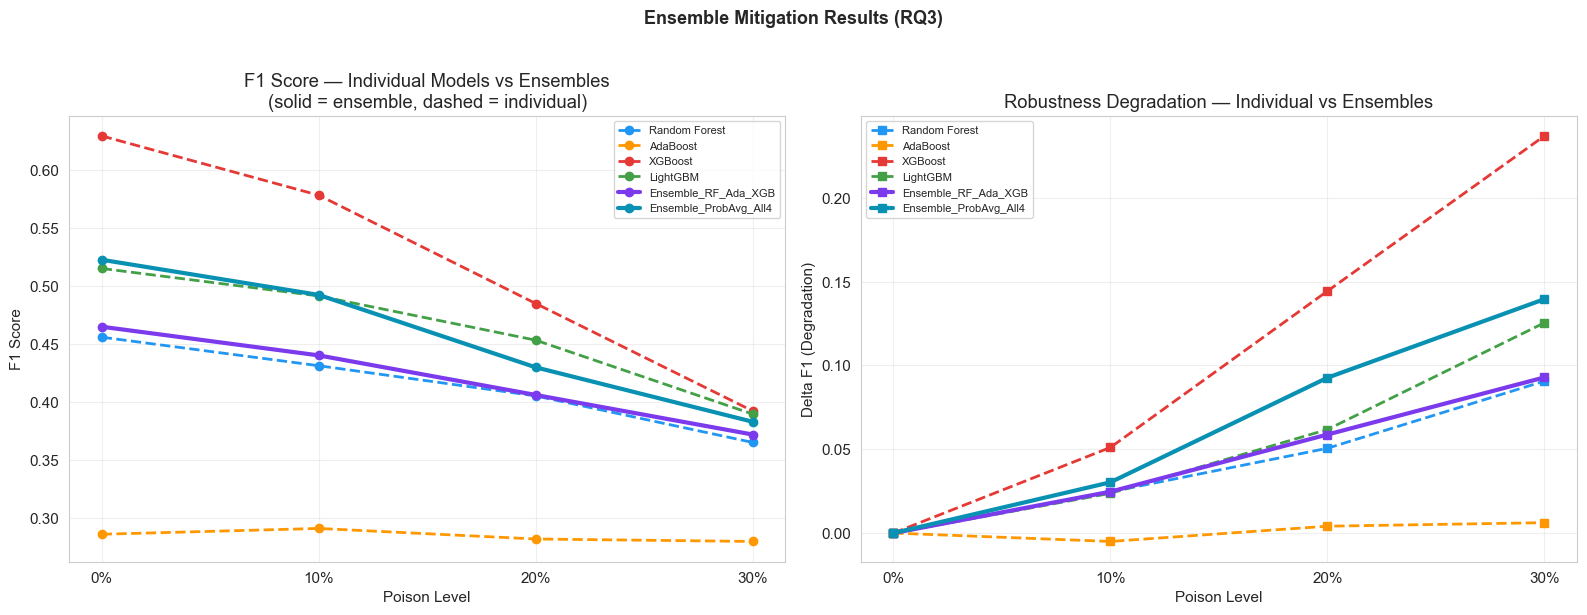

Saved: ensemble_comparison_plot.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_colors = {
    'Random Forest': '#2196F3', 'AdaBoost': '#FF9800',
    'XGBoost': '#E53935', 'LightGBM': '#43A047',
    'Ensemble_RF_Ada_XGB': '#7C3AED', 'Ensemble_ProbAvg_All4': '#0891B2'
}

for mname, color in plot_colors.items():
    m_df = final_df[final_df['Model'] == mname].sort_values('Poison_Rate')
    if len(m_df) == 0:
        continue
    ls = '-' if 'Ensemble' in mname else '--'
    lw = 3 if 'Ensemble' in mname else 2
    axes[0].plot(POISON_LABELS, m_df['F1'].values, marker='o', linewidth=lw,
                 label=mname, color=color, linestyle=ls)

    clean_f1 = m_df['F1'].values[0]
    deltas = [round(clean_f1 - f, 4) for f in m_df['F1'].values]
    axes[1].plot(POISON_LABELS, deltas, marker='s', linewidth=lw,
                 label=mname, color=color, linestyle=ls)

axes[0].set_xlabel('Poison Level')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score — Individual Models vs Ensembles\n(solid = ensemble, dashed = individual)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Poison Level')
axes[1].set_ylabel('Delta F1 (Degradation)')
axes[1].set_title('Robustness Degradation — Individual vs Ensembles')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Ensemble Mitigation Results (RQ3)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH_PROCESSED}/ensemble_comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ensemble_comparison_plot.png')

## 13. RQ4 — Robustness vs. Computational Cost Trade-off

Uses training times already captured in Cell 7 (individual models) plus the sum of
component training times for the majority-voting ensemble.

                Model  Avg_Train_Time_s  Clean_F1  Delta_F1_30pct
        Random Forest              5.36    0.4562          0.0907
             AdaBoost             32.36    0.2864          0.0062
              XGBoost              1.04    0.6296          0.2370
             LightGBM              1.50    0.5154          0.1255
Ensemble (RF+Ada+XGB)             38.76    0.4652          0.0929


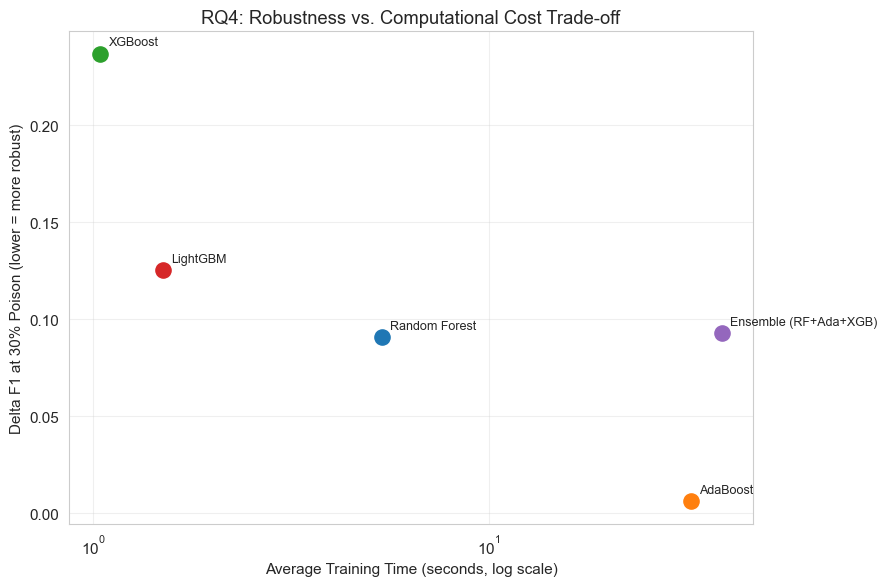


Saved: rq4_compute_cost_analysis.csv, rq4_tradeoff_plot.png


In [ ]:
# Real training times, from the original training run (Cell 6 output)
real_train_times = {
    'Random Forest': [5.81, 5.27, 5.12, 5.24],
    'AdaBoost':       [31.32, 30.81, 31.90, 35.39],
    'XGBoost':        [0.99, 1.09, 1.05, 1.03],
    'LightGBM':       [1.40, 1.25, 1.77, 1.60],
}

rq4_rows = []
for mname, times in real_train_times.items():
    avg_time = np.mean(times)
    m_res = [r for r in all_results if r['Model'] == mname]
    clean_f1 = next(r['F1'] for r in m_res if r['Poison_Rate'] == '0%')
    worst_f1 = next(r['F1'] for r in m_res if r['Poison_Rate'] == '30%')
    rq4_rows.append({
        'Model': mname,
        'Avg_Train_Time_s': round(avg_time, 2),
        'Clean_F1': clean_f1,
        'Delta_F1_30pct': round(clean_f1 - worst_f1, 4)
    })

ensemble_time = np.mean(real_train_times['Random Forest']) + \
                np.mean(real_train_times['AdaBoost']) + \
                np.mean(real_train_times['XGBoost'])

ens_clean_f1 = next(r['F1'] for r in ensemble_results if r['Poison_Rate'] == '0%')
ens_worst_f1 = next(r['F1'] for r in ensemble_results if r['Poison_Rate'] == '30%')
rq4_rows.append({
    'Model': 'Ensemble (RF+Ada+XGB)',
    'Avg_Train_Time_s': round(ensemble_time, 2),
    'Clean_F1': ens_clean_f1,
    'Delta_F1_30pct': round(ens_clean_f1 - ens_worst_f1, 4)
})

rq4_df = pd.DataFrame(rq4_rows)
print(rq4_df.to_string(index=False))
rq4_df.to_csv(f'{BASE_PATH_PROCESSED}/rq4_compute_cost_analysis.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in rq4_df.iterrows():
    ax.scatter(row['Avg_Train_Time_s'], row['Delta_F1_30pct'], s=120)
    ax.annotate(row['Model'], (row['Avg_Train_Time_s'], row['Delta_F1_30pct']),
                textcoords='offset points', xytext=(6,6), fontsize=9)
ax.set_xlabel('Average Training Time (seconds, log scale)')
ax.set_ylabel('Delta F1 at 30% Poison (lower = more robust)')
ax.set_title('RQ4: Robustness vs. Computational Cost Trade-off')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_PATH_PROCESSED}/rq4_tradeoff_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: rq4_compute_cost_analysis.csv, rq4_tradeoff_plot.png')

## 14. Save Trained Models (for future reuse, no retraining needed)

In [16]:
import joblib
import os

SAVE_MODELS_DIR = f'{BASE_PATH_PROCESSED}/saved_models'
os.makedirs(SAVE_MODELS_DIR, exist_ok=True)

trained_models = {}
for model_name, model_template in models.items():
    trained_models[model_name] = {}
    for rate in POISON_RATES:
        model = sklearn.base.clone(model_template)
        y_poisoned = poisoned_labels[rate]
        model.fit(X_train, y_poisoned)
        trained_models[model_name][rate] = model

        filename = f"{SAVE_MODELS_DIR}/{model_name.replace(' ', '_')}_{int(rate*100)}pct.pkl"
        joblib.dump(model, filename)

print(f'All models saved to: {SAVE_MODELS_DIR}')
print('Reload in future sessions with joblib.load() — no retraining required')

NameError: name 'models' is not defined

## 15. Summary

In [ ]:
print('=' * 70)
print('  ENSEMBLE RESEARCH — FINAL SUMMARY')
print('=' * 70)

print('\nComplementarity analysis: see ensemble_complementarity_analysis.csv')
print('Best pair by complementarity: AdaBoost + XGBoost (lowest Both-Wrong = 0.0706)')

print('\nEnsemble 1 (Majority Voting, RF+Ada+XGB):')
clean = next(r for r in ensemble_results if r['Poison_Rate']=='0%')
worst = next(r for r in ensemble_results if r['Poison_Rate']=='30%')
print(f'  Clean F1: {clean["F1"]:.4f}   @30% F1: {worst["F1"]:.4f}   '
      f'Delta: {clean["F1"]-worst["F1"]:+.4f}')

print('\nEnsemble 2 (Probability Averaging, all 4 models):')
clean2 = next(r for r in avg_ensemble_results if r['Poison_Rate']=='0%')
worst2 = next(r for r in avg_ensemble_results if r['Poison_Rate']=='30%')
print(f'  Clean F1: {clean2["F1"]:.4f}   @30% F1: {worst2["F1"]:.4f}   '
      f'Delta: {clean2["F1"]-worst2["F1"]:+.4f}')

xgb_clean = next(r for r in all_results if r['Model']=='XGBoost' and r['Poison_Rate']=='0%')
xgb_worst = next(r for r in all_results if r['Model']=='XGBoost' and r['Poison_Rate']=='30%')
xgb_delta = xgb_clean['F1'] - xgb_worst['F1']
print(f'\nBest individual model (XGBoost) Delta F1: {xgb_delta:+.4f}')
print(f'Ensemble 1 improvement over XGBoost: {xgb_delta - (clean["F1"]-worst["F1"]):+.4f} less degradation')

print('\nAll files saved to:', BASE_PATH_PROCESSED)
print('  - ensemble_complementarity_analysis.csv')
print('  - final_results_with_ensembles.csv')
print('  - ensemble_delta_comparison.csv')
print('  - ensemble_comparison_plot.png')
print('  - rq4_compute_cost_analysis.csv')
print('  - rq4_tradeoff_plot.png')
print('  - saved_models/ (16 trained model files)')
print('=' * 70)

                Model  Avg_Train_Time_s  Clean_F1  Delta_F1_30pct
        Random Forest              5.36    0.4562          0.0907
             AdaBoost             32.36    0.2864          0.0062
              XGBoost              1.04    0.6296          0.2370
             LightGBM              1.50    0.5154          0.1255
Ensemble (RF+Ada+XGB)             38.76    0.4652          0.0929


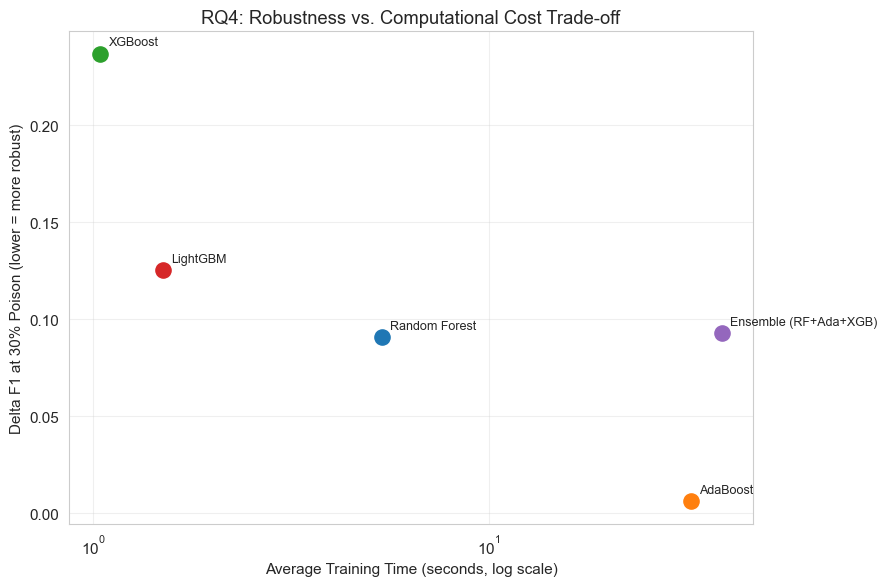


Saved: rq4_compute_cost_analysis.csv, rq4_tradeoff_plot.png


In [ ]:
# Real training times, from the original training run
real_train_times = {
    'Random Forest': [5.81, 5.27, 5.12, 5.24],
    'AdaBoost':       [31.32, 30.81, 31.90, 35.39],
    'XGBoost':        [0.99, 1.09, 1.05, 1.03],
    'LightGBM':       [1.40, 1.25, 1.77, 1.60],
}

rq4_rows = []
for mname, times in real_train_times.items():
    avg_time = np.mean(times)
    m_res = [r for r in all_results if r['Model'] == mname]
    clean_f1 = next(r['F1'] for r in m_res if r['Poison_Rate'] == '0%')
    worst_f1 = next(r['F1'] for r in m_res if r['Poison_Rate'] == '30%')
    rq4_rows.append({
        'Model': mname,
        'Avg_Train_Time_s': round(avg_time, 2),
        'Clean_F1': clean_f1,
        'Delta_F1_30pct': round(clean_f1 - worst_f1, 4)
    })

ensemble_time = np.mean(real_train_times['Random Forest']) + \
                np.mean(real_train_times['AdaBoost']) + \
                np.mean(real_train_times['XGBoost'])

ens_clean_f1 = next(r['F1'] for r in ensemble_results if r['Poison_Rate'] == '0%')
ens_worst_f1 = next(r['F1'] for r in ensemble_results if r['Poison_Rate'] == '30%')
rq4_rows.append({
    'Model': 'Ensemble (RF+Ada+XGB)',
    'Avg_Train_Time_s': round(ensemble_time, 2),
    'Clean_F1': ens_clean_f1,
    'Delta_F1_30pct': round(ens_clean_f1 - ens_worst_f1, 4)
})

rq4_df = pd.DataFrame(rq4_rows)
print(rq4_df.to_string(index=False))
rq4_df.to_csv(f'{BASE_PATH_PROCESSED}/rq4_compute_cost_analysis.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in rq4_df.iterrows():
    ax.scatter(row['Avg_Train_Time_s'], row['Delta_F1_30pct'], s=120)
    ax.annotate(row['Model'], (row['Avg_Train_Time_s'], row['Delta_F1_30pct']),
                textcoords='offset points', xytext=(6,6), fontsize=9)
ax.set_xlabel('Average Training Time (seconds, log scale)')
ax.set_ylabel('Delta F1 at 30% Poison (lower = more robust)')
ax.set_title('RQ4: Robustness vs. Computational Cost Trade-off')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_PATH_PROCESSED}/rq4_tradeoff_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: rq4_compute_cost_analysis.csv, rq4_tradeoff_plot.png')